In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = sns.load_dataset("mpg")
df = df[['displacement', 'mpg']]
df.dropna(inplace=True)
df.head()

,displacement,mpg
0,307.0,18.0
1,350.0,15.0
2,318.0,18.0
3,304.0,16.0
4,302.0,17.0


In [3]:
X = df['displacement'].values
y = df['mpg'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
linear_model = LinearRegression()
linear_model.fit(X_train.reshape(-1, 1), y_train)
y_pred_linear = linear_model.predict(X_test.reshape(-1, 1))

print("MSE: ", mean_squared_error(y_test, y_pred_linear))
print("R2 : ", r2_score(y_test, y_pred_linear))

MSE:  18.102543998358946
R2 :  0.6633114869465596


In [5]:
poly2 = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
poly2.fit(X_train.reshape(-1, 1), y_train)
y_pred2 = poly2.predict(X_test.reshape(-1, 1))

print("MSE: ", mean_squared_error(y_test, y_pred2))
print("R2 : ", r2_score(y_test, y_pred2))

MSE:  15.10735356108076
R2 :  0.7190189176110284


In [6]:
poly3 = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)
poly3.fit(X_train.reshape(-1, 1), y_train)
y_pred3 = poly3.predict(X_test.reshape(-1, 1))

print("MSE: ", mean_squared_error(y_test, y_pred3))
print("R2 : ", r2_score(y_test, y_pred3))

MSE:  16.369649051540456
R2 :  0.6955415327884606


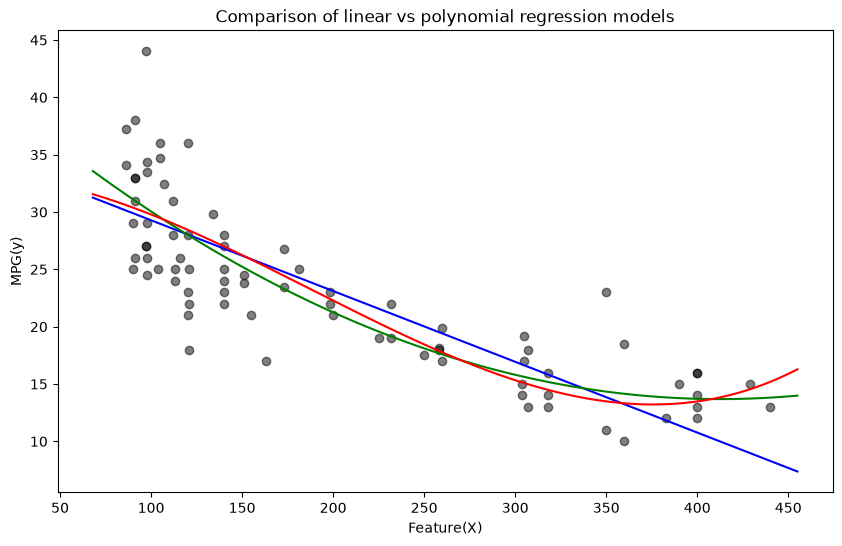

In [7]:
X_line = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', alpha=0.5)
plt.plot(X_line, linear_model.predict(X_line), color='blue')
plt.plot(X_line, poly2.predict(X_line), color='green')
plt.plot(X_line, poly3.predict(X_line), color='red')
plt.xlabel('Feature(X)')
plt.ylabel('MPG(y)')
plt.title('Comparison of linear vs polynomial regression models')
plt.show()